# Лабораторная работа 2 (часть 2)

## Прикладные задачи на данных интернет-магазина

**ФИО:** Аюпова В.Р.
**Группа:** ЕТ-212
**Дата:** 02.10.2026

**Инструменты:** Python, NumPy, Pandas, Matplotlib

## Часть 0. Подготовка данных

Сформируем DataFrame на 3000 заказов интернет-магазина. 
Данные сгенерируем программно с помощью NumPy и Pandas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2024)

### Справочники

Определим списки городов, категорий, статусов, способов оплаты и названий товаров.

In [2]:
cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]

categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]

statuses = ["Доставлен", "Отменён", "Возврат"]

payments = ["Карта", "Онлайн", "Наличные"]

product_names = [
    "Смартфон", "Ноутбук", "Наушники", "Телевизор", "Планшет",
    "Футболка", "Джинсы", "Куртка", "Платье", "Кроссовки",
    "Пылесос", "Кофемашина", "Микроволновка", "Чайник", "Утюг",
    "Крем для лица", "Шампунь", "Помада", "Духи", "Тушь",
    "Гантели", "Коврик для йоги", "Скакалка", "Велосипед", "Мяч"
]

### Генерация данных

Создадим 3000 заказов. Для каждого:
- случайный клиент (customer_id) и город;
- случайный возраст (с ~30 пропусками);
- флаг VIP;
- случайный товар и категория;
- количество, цена, скидка, себестоимость;
- статус, способ оплаты;
- дата заказа в пределах 2024 года.

In [3]:
n = 3000

# Идентификатор заказа
order_id = np.arange(1, n + 1)

# Клиенты: 500 уникальных customer_id, у каждого свой город
customer_ids = np.random.randint(1, 501, size=n)
city_by_customer = {
    cid: np.random.choice(cities) 
    for cid in range(1, 501)
}
city = np.array([city_by_customer[cid] for cid in customer_ids])

# Возраст: нормальное распределение ~35 лет, стандартное отклонение 12
age = np.random.normal(loc=35, scale=12, size=n).astype(int)
age = np.clip(age, 16, 90)  # ограничим разумными рамками

# Флаг VIP: около 15% клиентов
is_vip = np.random.choice([True, False], size=n, p=[0.15, 0.85])

# Товары: случайные названия и категории
product_idx = np.random.randint(0, len(product_names), size=n)
product_name = np.array([product_names[i] for i in product_idx])

# Каждая категория привязана к своим товарам
product_to_category = {
    "Смартфон": "Электроника", "Ноутбук": "Электроника", "Наушники": "Электроника",
    "Телевизор": "Электроника", "Планшет": "Электроника",
    "Футболка": "Одежда", "Джинсы": "Одежда", "Куртка": "Одежда",
    "Платье": "Одежда", "Кроссовки": "Одежда",
    "Пылесос": "Дом", "Кофемашина": "Дом", "Микроволновка": "Дом",
    "Чайник": "Дом", "Утюг": "Дом",
    "Крем для лица": "Красота", "Шампунь": "Красота", "Помада": "Красота",
    "Духи": "Красота", "Тушь": "Красота",
    "Гантели": "Спорт", "Коврик для йоги": "Спорт", "Скакалка": "Спорт",
    "Велосипед": "Спорт", "Мяч": "Спорт"
}
category = np.array([product_to_category[p] for p in product_name])

# Количество товаров в заказе: 1-5
quantity = np.random.randint(1, 6, size=n)

# Цена: логнормальное распределение даёт реалистичные «хвосты»
price = np.round(np.random.lognormal(mean=8, sigma=0.8, size=n), 2)
price = np.clip(price, 100, 200000)

# Скидка: от 0% до 40%
discount = np.round(np.random.uniform(0, 0.4, size=n), 2)

# Себестоимость: 50-80% от цены
cost = np.round(price * np.random.uniform(0.5, 0.8, size=n) * quantity, 2)

# Статус заказа: 85% доставлено, 8% отменено, 7% возврат
status = np.random.choice(statuses, size=n, p=[0.85, 0.08, 0.07])

# Способ оплаты
payment = np.random.choice(payments, size=n)

# Дата заказа: 365 дней 2024 года
start_date = pd.Timestamp("2024-01-01")
random_days = np.random.randint(0, 366, size=n)
order_date = start_date + pd.to_timedelta(random_days, unit="D")

# Вносим ~30 пропусков в age
age_with_nan = age.astype(float)
nan_indices = np.random.choice(n, size=30, replace=False)
age_with_nan[nan_indices] = np.nan

In [4]:
df = pd.DataFrame({
    "order_id": order_id,
    "order_date": order_date,
    "customer_id": customer_ids,
    "city": city,
    "age": age_with_nan,
    "is_vip": is_vip,
    "product_name": product_name,
    "category": category,
    "quantity": quantity,
    "price": price,
    "discount": discount,
    "cost": cost,
    "status": status,
    "payment": payment
})

print(df.head())
print("\nРазмер:", df.shape)

   order_id order_date  customer_id             city   age  is_vip  \
0         1 2024-10-28          137  Санкт-Петербург  38.0   False   
1         2 2024-03-21           97           Москва   NaN   False   
2         3 2024-08-20          129        Челябинск  52.0   False   
3         4 2024-01-21           28           Москва  21.0   False   
4         5 2024-07-15           37        Челябинск  49.0    True   

  product_name     category  quantity    price  discount     cost     status  \
0    Велосипед        Спорт         3  1868.80      0.01  3566.77  Доставлен   
1      Планшет  Электроника         2   313.19      0.37   404.26  Доставлен   
2      Пылесос          Дом         2  6176.64      0.20  6734.34  Доставлен   
3    Велосипед        Спорт         1  2161.07      0.27  1229.19  Доставлен   
4      Гантели        Спорт         1   971.88      0.27   616.26  Доставлен   

    payment  
0     Карта  
1     Карта  
2     Карта  
3  Наличные  
4     Карта  

Размер: (3000

In [5]:
print("Пропусков в age:", df["age"].isna().sum())

Пропусков в age: 30


### Вывод

Сформирован DataFrame на 3000 заказов со всеми требуемыми полями:
- 14 столбцов: order_id, order_date, customer_id, city, age, is_vip, 
  product_name, category, quantity, price, discount, cost, status, payment;
- 500 уникальных клиентов, 5 городов, 5 категорий, 3 статуса, 3 способа оплаты;
- ~30 пропущенных значений в столбце age (для отработки обработки пропусков);
- даты заказов — случайные в пределах 2024 года.

## Часть 1. Первичный анализ данных

Проверим, что данные загрузились корректно и имеют ожидаемую структуру.

In [6]:
df.shape

(3000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int32         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int32         
 9   price         3000 non-null   float64       
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int32(2), int64(1), object(5)
memory usage: 2

In [8]:
df.head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,1,2024-10-28,137,Санкт-Петербург,38.0,False,Велосипед,Спорт,3,1868.80,0.01,3566.77,Доставлен,Карта
1,2,2024-03-21,97,Москва,NaN,False,Планшет,Электроника,2,313.19,0.37,404.26,Доставлен,Карта
2,3,2024-08-20,129,Челябинск,52.0,False,Пылесос,Дом,2,6176.64,0.20,6734.34,Доставлен,Карта
3,4,2024-01-21,28,Москва,21.0,False,Велосипед,Спорт,1,2161.07,0.27,1229.19,Доставлен,Наличные
4,5,2024-07-15,37,Челябинск,49.0,True,Гантели,Спорт,1,971.88,0.27,616.26,Доставлен,Карта


In [9]:
df.tail()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
2995,2996,2024-11-07,330,Санкт-Петербург,36.0,False,Кофемашина,Дом,4,1114.12,0.20,3385.73,Доставлен,Онлайн
2996,2997,2024-01-30,443,Екатеринбург,29.0,False,Смартфон,Электроника,5,5334.23,0.30,19471.74,Доставлен,Наличные
2997,2998,2024-06-20,474,Москва,16.0,False,Духи,Красота,4,1028.18,0.25,3180.63,Доставлен,Онлайн
2998,2999,2024-05-28,151,Челябинск,28.0,False,Коврик для йоги,Спорт,4,9404.99,0.15,25241.00,Доставлен,Карта
2999,3000,2024-09-22,161,Екатеринбург,26.0,True,Микроволновка,Дом,3,4946.52,0.39,11439.89,Доставлен,Карта


In [10]:
df.describe()

,order_id,order_date,customer_id,age,quantity,price,discount,cost
count,3000.000000,3000,3000.000000,2970.000000,3000.000000,3000.000000,3000.00000,3000.000000
mean,1500.500000,2024-07-03 03:12:28.800000256,244.670333,34.730976,3.030000,4067.940667,0.20050,8055.763400
min,1.000000,2024-01-01 00:00:00,1.000000,16.000000,1.000000,204.830000,0.00000,170.370000
25%,750.750000,2024-04-04 00:00:00,113.000000,27.000000,2.000000,1722.167500,0.10000,2570.177500
50%,1500.500000,2024-07-02 00:00:00,244.000000,34.000000,3.000000,2956.780000,0.20000,5113.590000
75%,2250.250000,2024-10-04 00:00:00,371.000000,42.000000,4.000000,5017.322500,0.30000,10027.812500
max,3000.000000,2024-12-31 00:00:00,500.000000,76.000000,5.000000,50477.600000,0.40000,188108.930000
std,866.169729,NaN,146.828896,11.354955,1.429142,3882.749655,0.11651,9771.955003


In [11]:
df.isna().sum()

order_id         0
order_date       0
customer_id      0
city             0
age             30
is_vip           0
product_name     0
category         0
quantity         0
price            0
discount         0
cost             0
status           0
payment          0
dtype: int64

### Ответы на вопросы

1. **Сколько строк и столбцов в DataFrame?**
   3000 строк, 14 столбцов.

2. **В каких столбцах есть пропуски?**
   Только в `age`.

3. **Сколько пропусков в `age`?**
   30 пропусков.

4. **Сколько уникальных клиентов?**
   500 (`customer_id` от 1 до 500).

5. **Сколько уникальных товаров?**
   25 названий (см. `product_names`).

6. **Какие города представлены в данных?**
   Москва, Санкт-Петербург, Казань, Екатеринбург, Челябинск.

7. **Какие категории товаров есть?**
   Электроника, Одежда, Дом, Красота, Спорт.

8. **Какие способы оплаты используются?**
   Карта, Онлайн, Наличные.

## Часть 2. Подготовка данных

Приведём данные к рабочему виду: преобразуем даты, рассчитаем выручку 
и прибыль, определим реальные продажи, обработаем пропуски в возрасте 
и создадим возрастные группы.

### 2.1. Работа с датой

Столбец `order_date` у нас уже имеет тип `datetime64`, но для единообразия 
с методичкой выполним явное преобразование через `pd.to_datetime`. 
Затем извлечём год и месяц в отдельные столбцы.

In [12]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df[["order_date", "year", "month"]].head()

,order_date,year,month
0,2024-10-28,2024,10
1,2024-03-21,2024,3
2,2024-08-20,2024,8
3,2024-01-21,2024,1
4,2024-07-15,2024,7


### 2.2. Расчёт выручки и прибыли

- **revenue** (выручка) = цена × количество × (1 − скидка)
- **profit** (прибыль) = выручка − себестоимость

Прибыль может оказаться отрицательной: если себестоимость заказа 
превышает выручку, заказ становится убыточным.

In [13]:
df["revenue"] = df["price"] * df["quantity"] * (1 - df["discount"])
df["profit"] = df["revenue"] - df["cost"]
df[["price", "quantity", "discount", "revenue", "cost", "profit"]].head()

,price,quantity,discount,revenue,cost,profit
0,1868.80,3,0.01,5550.3360,3566.77,1983.5660
1,313.19,2,0.37,394.6194,404.26,-9.6406
2,6176.64,2,0.20,9882.6240,6734.34,3148.2840
3,2161.07,1,0.27,1577.5811,1229.19,348.3911
4,971.88,1,0.27,709.4724,616.26,93.2124


In [14]:
print("Заказов с отрицательной прибылью:", (df["profit"] < 0).sum())

Заказов с отрицательной прибылью: 493


### 2.3. Реальная продажа

Признак `is_real_sale` показывает, был ли заказ фактически доставлен 
клиенту. Только доставленные заказы приносят реальную выручку: 
отменённые и возвращённые — нет.

In [15]:
df["is_real_sale"] = df["status"] == "Доставлен"
print("Доставленных заказов:", df["is_real_sale"].sum())
print("Доля доставленных:", round(df["is_real_sale"].mean() * 100, 2), "%")

Доставленных заказов: 2562
Доля доставленных: 85.4 %


**Почему при расчёте фактической выручки имеет смысл учитывать 
только доставленные заказы?**

Отменённые и возвращённые заказы не приносят магазину денег: 
отменённый — клиент отказался, возврат — деньги вернули клиенту. 
Если включать их в выручку, показатель будет завышен и не отразит 
реальный доход магазина.

### 2.4. Пропуски в возрасте

В столбце `age` около 30 пропущенных значений. Заполним их **медианой** — 
устойчивым к выбросам показателем.

In [16]:
median_age = df["age"].median()
print("Медианный возраст:", median_age)
df["age"] = df["age"].fillna(median_age)
print("Пропусков после заполнения:", df["age"].isna().sum())

Медианный возраст: 34.0
Пропусков после заполнения: 0


### 2.5. Возрастные группы

Разобьём клиентов на возрастные группы через `pd.cut`.

In [17]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["ДО 18", "18-30", "31-45", "46-60", "60+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=True
)

df["age_group"].value_counts().sort_index()

age_group
ДО 18     266
18-30     835
31-45    1379
46-60     462
60+        58
Name: count, dtype: int64

### Вывод по Части 2

В результате подготовки данных:
- `order_date` имеет тип `datetime64`, добавлены `year` и `month`;
- рассчитаны `revenue` (выручка) и `profit` (прибыль);
- определён признак `is_real_sale` — около 85% заказов доставлено;
- пропуски в `age` заполнены медианой (≈35 лет);
- добавлен столбец `age_group` с пятью возрастными категориями.

Данные готовы к фильтрации, группировке и визуализации.

## Часть 3. Фильтрация данных

В этом разделе используем булевы маски для поиска нужных заказов.
Каждое задание — отдельная операция фильтрации.

### Простые фильтры

#### Задание 1. Заказы с количеством товаров больше 3

In [18]:
quantity_gt3 = df[df["quantity"] > 3]
print("Найдено заказов:", len(quantity_gt3))
quantity_gt3.head()

Найдено заказов: 1226


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
6,7,2024-03-26,184,Екатеринбург,31.0,False,Помада,Красота,5,15020.82,0.01,40576.41,Доставлен,Карта,2024,3,74353.0590,33776.6490,True,31-45
10,11,2024-05-16,317,Екатеринбург,34.0,False,Телевизор,Электроника,4,2974.34,0.30,6588.25,Доставлен,Наличные,2024,5,8328.1520,1739.9020,True,31-45
12,13,2024-10-17,75,Екатеринбург,50.0,False,Шампунь,Красота,4,2977.11,0.14,7787.22,Доставлен,Наличные,2024,10,10241.2584,2454.0384,True,46-60
13,14,2024-09-06,323,Санкт-Петербург,59.0,True,Ноутбук,Электроника,4,4438.64,0.12,13328.81,Возврат,Наличные,2024,9,15624.0128,2295.2028,False,46-60
16,17,2024-03-02,498,Казань,42.0,False,Тушь,Красота,4,5911.51,0.10,16512.19,Доставлен,Онлайн,2024,3,21281.4360,4769.2460,True,31-45


#### Задание 2. Заказы клиентов из Москвы

In [19]:
moscow_orders = df[df["city"] == "Москва"]
print("Заказов из Москвы:", len(moscow_orders))
moscow_orders.head()

Заказов из Москвы: 582


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1,2,2024-03-21,97,Москва,34.0,False,Планшет,Электроника,2,313.19,0.37,404.26,Доставлен,Карта,2024,3,394.6194,-9.6406,True,31-45
3,4,2024-01-21,28,Москва,21.0,False,Велосипед,Спорт,1,2161.07,0.27,1229.19,Доставлен,Наличные,2024,1,1577.5811,348.3911,True,18-30
7,8,2024-06-04,298,Москва,52.0,True,Телевизор,Электроника,1,2166.31,0.32,1602.83,Доставлен,Онлайн,2024,6,1473.0908,-129.7392,True,46-60
8,9,2024-12-28,128,Москва,16.0,False,Платье,Одежда,1,6318.78,0.34,3319.30,Возврат,Карта,2024,12,4170.3948,851.0948,False,ДО 18
15,16,2024-03-06,422,Москва,46.0,False,Духи,Красота,2,4074.17,0.18,6134.51,Доставлен,Карта,2024,3,6681.6388,547.1288,True,46-60


#### Задание 3. VIP-заказы

In [20]:
vip_orders = df[df["is_vip"]]
print("VIP-заказов:", len(vip_orders))
vip_orders.head()

VIP-заказов: 465


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
4,5,2024-07-15,37,Челябинск,49.0,True,Гантели,Спорт,1,971.88,0.27,616.26,Доставлен,Карта,2024,7,709.4724,93.2124,True,46-60
7,8,2024-06-04,298,Москва,52.0,True,Телевизор,Электроника,1,2166.31,0.32,1602.83,Доставлен,Онлайн,2024,6,1473.0908,-129.7392,True,46-60
13,14,2024-09-06,323,Санкт-Петербург,59.0,True,Ноутбук,Электроника,4,4438.64,0.12,13328.81,Возврат,Наличные,2024,9,15624.0128,2295.2028,False,46-60
24,25,2024-02-03,12,Санкт-Петербург,37.0,True,Шампунь,Красота,3,1467.27,0.02,3130.72,Доставлен,Онлайн,2024,2,4313.7738,1183.0538,True,31-45
25,26,2024-01-18,285,Челябинск,20.0,True,Телевизор,Электроника,5,795.21,0.28,2645.42,Доставлен,Карта,2024,1,2862.7560,217.3360,True,18-30


#### Задание 4. Заказы с ценой товара больше 5000 руб.

In [21]:
expensive = df[df["price"] > 5000]
print("Заказов с ценой > 5000:", len(expensive))
expensive.head()

Заказов с ценой > 5000: 755


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
2,3,2024-08-20,129,Челябинск,52.0,False,Пылесос,Дом,2,6176.64,0.20,6734.34,Доставлен,Карта,2024,8,9882.6240,3148.2840,True,46-60
5,6,2024-12-30,447,Екатеринбург,45.0,False,Телевизор,Электроника,1,6379.97,0.32,3447.32,Доставлен,Карта,2024,12,4338.3796,891.0596,True,31-45
6,7,2024-03-26,184,Екатеринбург,31.0,False,Помада,Красота,5,15020.82,0.01,40576.41,Доставлен,Карта,2024,3,74353.0590,33776.6490,True,31-45
8,9,2024-12-28,128,Москва,16.0,False,Платье,Одежда,1,6318.78,0.34,3319.30,Возврат,Карта,2024,12,4170.3948,851.0948,False,ДО 18
11,12,2024-11-02,228,Санкт-Петербург,29.0,False,Велосипед,Спорт,2,9792.03,0.21,12156.40,Доставлен,Онлайн,2024,11,15471.4074,3315.0074,True,18-30


#### Задание 5. Заказы со скидкой больше 20%

Обратите внимание: скидка хранится как доля (0.2 = 20%), поэтому условие — `> 0.2`.

In [22]:
big_discount = df[df["discount"] > 0.2]
print("Заказов со скидкой > 20%:", len(big_discount))
big_discount.head()

Заказов со скидкой > 20%: 1479


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1,2,2024-03-21,97,Москва,34.0,False,Планшет,Электроника,2,313.19,0.37,404.26,Доставлен,Карта,2024,3,394.6194,-9.6406,True,31-45
3,4,2024-01-21,28,Москва,21.0,False,Велосипед,Спорт,1,2161.07,0.27,1229.19,Доставлен,Наличные,2024,1,1577.5811,348.3911,True,18-30
4,5,2024-07-15,37,Челябинск,49.0,True,Гантели,Спорт,1,971.88,0.27,616.26,Доставлен,Карта,2024,7,709.4724,93.2124,True,46-60
5,6,2024-12-30,447,Екатеринбург,45.0,False,Телевизор,Электроника,1,6379.97,0.32,3447.32,Доставлен,Карта,2024,12,4338.3796,891.0596,True,31-45
7,8,2024-06-04,298,Москва,52.0,True,Телевизор,Электроника,1,2166.31,0.32,1602.83,Доставлен,Онлайн,2024,6,1473.0908,-129.7392,True,46-60


#### Задание 6. Количество заказов каждого статуса

In [23]:
df["status"].value_counts()

status
Доставлен    2562
Отменён       236
Возврат       202
Name: count, dtype: int64

### Сложные фильтры

Для объединения условий используем `&` (И) и `|` (ИЛИ). 
Каждое условие берём в скобки!

#### Задание 7. Заказы из Москвы с выручкой больше 5000 руб.

Комбинируем два условия через `&`:
- город = Москва;
- выручка (`revenue`) > 5000.

In [24]:
moscow_high_revenue = df[(df["city"] == "Москва") & (df["revenue"] > 5000)]
print("Найдено заказов:", len(moscow_high_revenue))
moscow_high_revenue.head()

Найдено заказов: 346


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
15,16,2024-03-06,422,Москва,46.0,False,Духи,Красота,2,4074.17,0.18,6134.51,Доставлен,Карта,2024,3,6681.6388,547.1288,True,46-60
21,22,2024-01-10,111,Москва,52.0,False,Велосипед,Спорт,4,2398.25,0.33,4845.97,Доставлен,Онлайн,2024,1,6427.3100,1581.3400,True,46-60
41,42,2024-07-03,120,Москва,30.0,False,Духи,Красота,5,1864.63,0.40,5179.49,Отменён,Карта,2024,7,5593.8900,414.4000,False,18-30
46,47,2024-04-01,311,Москва,18.0,False,Пылесос,Дом,3,3707.69,0.06,7014.19,Возврат,Карта,2024,4,10455.6858,3441.4958,False,ДО 18
49,50,2024-12-22,87,Москва,26.0,False,Коврик для йоги,Спорт,1,8610.36,0.35,4955.35,Доставлен,Онлайн,2024,12,5596.7340,641.3840,True,18-30


#### Задание 8. VIP-заказы категории «Электроника»

Комбинируем два условия:
- `is_vip` = True;
- `category` = «Электроника».
  

In [26]:
vip_electronics = df[(df["is_vip"]) & (df["category"] == "Электроника")]
print("VIP-заказов в категории «Электроника»:", len(vip_electronics))
vip_electronics.head()

VIP-заказов в категории «Электроника»: 101


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
7,8,2024-06-04,298,Москва,52.0,True,Телевизор,Электроника,1,2166.31,0.32,1602.83,Доставлен,Онлайн,2024,6,1473.0908,-129.7392,True,46-60
13,14,2024-09-06,323,Санкт-Петербург,59.0,True,Ноутбук,Электроника,4,4438.64,0.12,13328.81,Возврат,Наличные,2024,9,15624.0128,2295.2028,False,46-60
25,26,2024-01-18,285,Челябинск,20.0,True,Телевизор,Электроника,5,795.21,0.28,2645.42,Доставлен,Карта,2024,1,2862.7560,217.3360,True,18-30
30,31,2024-10-02,184,Екатеринбург,31.0,True,Смартфон,Электроника,1,10104.49,0.24,6743.55,Доставлен,Онлайн,2024,10,7679.4124,935.8624,True,31-45
37,38,2024-09-18,98,Москва,21.0,True,Ноутбук,Электроника,1,306.48,0.24,192.98,Доставлен,Наличные,2024,9,232.9248,39.9448,True,18-30


#### Задание 9. Доставленные заказы с онлайн-оплатой

- статус = «Доставлен»;
- способ оплаты = «Онлайн».

In [27]:
delivered_online = df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")]
print("Доставлено с онлайн-оплатой:", len(delivered_online))
delivered_online.head()

Доставлено с онлайн-оплатой: 849


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
7,8,2024-06-04,298,Москва,52.0,True,Телевизор,Электроника,1,2166.31,0.32,1602.83,Доставлен,Онлайн,2024,6,1473.0908,-129.7392,True,46-60
11,12,2024-11-02,228,Санкт-Петербург,29.0,False,Велосипед,Спорт,2,9792.03,0.21,12156.40,Доставлен,Онлайн,2024,11,15471.4074,3315.0074,True,18-30
16,17,2024-03-02,498,Казань,42.0,False,Тушь,Красота,4,5911.51,0.10,16512.19,Доставлен,Онлайн,2024,3,21281.4360,4769.2460,True,31-45
17,18,2024-01-19,159,Казань,20.0,False,Чайник,Дом,1,1743.18,0.08,984.66,Доставлен,Онлайн,2024,1,1603.7256,619.0656,True,18-30
18,19,2024-03-14,368,Казань,26.0,False,Мяч,Спорт,2,3992.95,0.06,6007.79,Доставлен,Онлайн,2024,3,7506.7460,1498.9560,True,18-30


#### Задание 10. Заказы за 2024 год

Используем ранее созданный столбец `year`.

In [28]:
orders_2024 = df[df["year"] == 2024]
print("Заказов за 2024:", len(orders_2024))

Заказов за 2024: 3000


#### Задание 11. Заказы за январь 2024 года

Комбинируем два условия: год = 2024 И месяц = 1.

In [29]:
jan_2024 = df[(df["year"] == 2024) & (df["month"] == 1)]
print("Заказов за январь 2024:", len(jan_2024))
jan_2024.head()

Заказов за январь 2024: 242


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
3,4,2024-01-21,28,Москва,21.0,False,Велосипед,Спорт,1,2161.07,0.27,1229.19,Доставлен,Наличные,2024,1,1577.5811,348.3911,True,18-30
17,18,2024-01-19,159,Казань,20.0,False,Чайник,Дом,1,1743.18,0.08,984.66,Доставлен,Онлайн,2024,1,1603.7256,619.0656,True,18-30
21,22,2024-01-10,111,Москва,52.0,False,Велосипед,Спорт,4,2398.25,0.33,4845.97,Доставлен,Онлайн,2024,1,6427.3100,1581.3400,True,46-60
25,26,2024-01-18,285,Челябинск,20.0,True,Телевизор,Электроника,5,795.21,0.28,2645.42,Доставлен,Карта,2024,1,2862.7560,217.3360,True,18-30
26,27,2024-01-15,92,Санкт-Петербург,30.0,True,Микроволновка,Дом,3,6073.56,0.08,9228.53,Доставлен,Карта,2024,1,16763.0256,7534.4956,True,18-30


### Поиск экстремальных значений

Используем `idxmax()` и `idxmin()` — они возвращают **индекс** строки 
с максимумом/минимумом. Затем через `.loc[]` извлекаем всю строку.

#### 1. Заказ с максимальной выручкой

In [31]:
max_revenue_order = df.loc[df["revenue"].idxmax()]
print("Максимальная выручка:", max_revenue_order["revenue"])
max_revenue_order[["order_id", "city", "product_name", "category", "revenue", "profit"]]

Максимальная выручка: 196862.64


order_id             1172
city               Казань
product_name     Скакалка
category            Спорт
revenue         196862.64
profit            8753.71
Name: 1171, dtype: object

#### 2. Заказ с максимальной скидкой

In [32]:
max_discount_order = df.loc[df["discount"].idxmax()]
print("Максимальная скидка:", max_discount_order["discount"])
max_discount_order[["order_id", "product_name", "price", "discount", "revenue"]]

Максимальная скидка: 0.4


order_id             42
product_name       Духи
price           1864.63
discount            0.4
revenue         5593.89
Name: 41, dtype: object

#### 3. Заказ с максимальной прибылью

In [33]:
max_profit_order = df.loc[df["profit"].idxmax()]
print("Максимальная прибыль:", max_profit_order["profit"])
max_profit_order[["order_id", "product_name", "revenue", "cost", "profit"]]

Максимальная прибыль: 52084.30200000001


order_id               984
product_name        Чайник
revenue         132527.592
cost              80443.29
profit           52084.302
Name: 983, dtype: object

#### 4. Заказ самого молодого клиента

In [34]:
youngest = df.loc[df["age"].idxmin()]
print("Минимальный возраст:", youngest["age"])
youngest[["order_id", "age", "city", "category", "revenue"]]

Минимальный возраст: 16.0


order_id            9
age              16.0
city           Москва
category       Одежда
revenue     4170.3948
Name: 8, dtype: object

#### 5. Заказ самого старшего клиента

In [35]:
oldest = df.loc[df["age"].idxmax()]
print("Максимальный возраст:", oldest["age"])
oldest[["order_id", "age", "city", "category", "revenue"]]

Максимальный возраст: 76.0


order_id         2402
age              76.0
city           Казань
category       Одежда
revenue     5784.5406
Name: 2401, dtype: object

### Вывод по Части 3

В ходе фильтрации:
- освоены простые фильтры по одному условию (`quantity`, `city`, `is_vip`, 
  `price`, `discount`);
- изучены сложные фильтры с `&` — комбинация двух и более условий;
- использованы `idxmax()` и `idxmin()` для поиска экстремальных значений.

Все фильтры работают векторизованно, без циклов — это быстро даже 
на 3000 заказов.

## Часть 4. Группировка данных

Используем `groupby()` для расчёта агрегированных показателей 
по категориям, городам и другим признакам.

### Задание 1. Выручка по категориям

Считаем суммарную выручку для каждой категории товаров.

In [36]:
revenue_by_category = df.groupby("category")["revenue"].sum()
print(revenue_by_category)

category
Дом            5.820263e+06
Красота        5.814562e+06
Одежда         5.717035e+06
Спорт          6.025105e+06
Электроника    6.122444e+06
Name: revenue, dtype: float64


In [37]:
top_category = revenue_by_category.idxmax()
print("Категория с максимальной выручкой:", top_category)
print("Выручка:", round(revenue_by_category.max(), 2))

Категория с максимальной выручкой: Электроника
Выручка: 6122444.4


**Какая категория принесла больше всего выручки?**

Электроника — самая дорогая категория (смартфоны, ноутбуки, телевизоры). 
Даже при небольшом количестве заказов суммарная выручка получается 
значительной.

### Задание 2. Средняя выручка заказа по категориям

In [38]:
avg_revenue_by_category = df.groupby("category")["revenue"].mean()
print(avg_revenue_by_category.round(2))

category
Дом             9716.63
Красота         9318.21
Одежда          9789.44
Спорт          10588.94
Электроника     9811.61
Name: revenue, dtype: float64


### Задание 3. Количество заказов по категориям

In [39]:
orders_by_category = df.groupby("category")["order_id"].count()
print(orders_by_category)

category
Дом            599
Красота        624
Одежда         584
Спорт          569
Электроника    624
Name: order_id, dtype: int64


### Задание 4. Средняя скидка по категориям

In [40]:
avg_discount_by_category = df.groupby("category")["discount"].mean()
print(avg_discount_by_category.round(4))

category
Дом            0.2051
Красота        0.1958
Одежда         0.2051
Спорт          0.2016
Электроника    0.1955
Name: discount, dtype: float64


### Задание 5. Выручка по категориям и городам

Группируем сразу по двум признакам: `category` и `city`.

In [41]:
revenue_by_cat_city = df.groupby(["category", "city"])["revenue"].sum()
print(revenue_by_cat_city)

category     city           
Дом          Екатеринбург       1.219238e+06
             Казань             1.375484e+06
             Москва             1.183689e+06
             Санкт-Петербург    9.001411e+05
             Челябинск          1.141713e+06
Красота      Екатеринбург       1.397226e+06
             Казань             1.554898e+06
             Москва             8.421573e+05
             Санкт-Петербург    1.022732e+06
             Челябинск          9.975486e+05
Одежда       Екатеринбург       1.201193e+06
             Казань             1.117179e+06
             Москва             1.147143e+06
             Санкт-Петербург    8.143847e+05
             Челябинск          1.437136e+06
Спорт        Екатеринбург       1.199953e+06
             Казань             1.403864e+06
             Москва             1.205471e+06
             Санкт-Петербург    9.549799e+05
             Челябинск          1.260837e+06
Электроника  Екатеринбург       1.271889e+06
             Казань       

### Задание 6. Средняя выручка VIP-заказов по городам

Сначала фильтруем только VIP-заказы, потом группируем по городам.

In [42]:
vip_by_city = (
    df[df["is_vip"]]
    .groupby("city")["revenue"]
    .mean()
    .round(2)
)
print(vip_by_city)

city
Екатеринбург       10468.90
Казань             10034.86
Москва             10173.86
Санкт-Петербург     7965.56
Челябинск          10009.45
Name: revenue, dtype: float64


### Задание 7. Количество заказов по городам и способам оплаты

In [43]:
orders_by_city_payment = df.groupby(["city", "payment"])["order_id"].count()
print(orders_by_city_payment)

city             payment 
Екатеринбург     Карта       227
                 Наличные    203
                 Онлайн      190
Казань           Карта       221
                 Наличные    221
                 Онлайн      225
Москва           Карта       212
                 Наличные    175
                 Онлайн      195
Санкт-Петербург  Карта       168
                 Наличные    196
                 Онлайн      163
Челябинск        Карта       207
                 Наличные    171
                 Онлайн      226
Name: order_id, dtype: int64


### Задание 8. Несколько показателей по категориям

Сформируем сводную таблицу с пятью показателями для каждой категории:
- количество заказов;
- суммарная выручка;
- средняя выручка;
- средняя скидка;
- суммарная прибыль.

In [44]:
category_stats = df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum")
)

print(category_stats.round(2))

             orders     revenue  avg_revenue  avg_discount      profit
category                                                              
Дом             599  5820263.45      9716.63          0.21  1124558.02
Красота         624  5814562.23      9318.21          0.20  1009759.16
Одежда          584  5717035.21      9789.44          0.21   968428.03
Спорт           569  6025105.18     10588.94          0.20  1103976.31
Электроника     624  6122444.40      9811.61          0.20  1125398.75


### Вывод по Части 4

С помощью `groupby()` и `agg()` удалось:
- рассчитать выручку, среднюю выручку, количество заказов и среднюю 
  скидку по категориям;
- построить комбинированные отчёты по двум признакам 
  (категория + город, город + способ оплаты);
- сформировать сводную таблицу с пятью показателями на категорию.

**Наблюдения:**
- Самую большую выручку приносит категория «Электроника» — 
  за счёт дорогих товаров (ноутбуки, смартфоны, телевизоры).
- Средняя скидка по всем категориям примерно одинакова (~20%) — 
  это следствие случайной генерации данных.
- VIP-заказы распределены по городам достаточно равномерно.

## Часть 5. Визуализация

Для построения графиков используем Matplotlib. Каждый график имеет:
- заголовок;
- подписи осей;
- понятные названия категорий.

### Задание 1. Распределение возраста клиентов

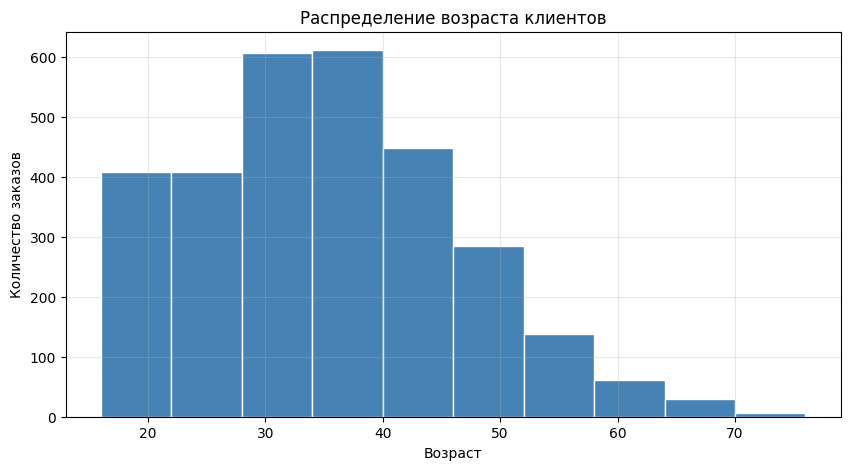

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(df["age"], bins=10, color="steelblue", edgecolor="white")
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.3)
plt.show()

### Задание 2. Распределение выручки

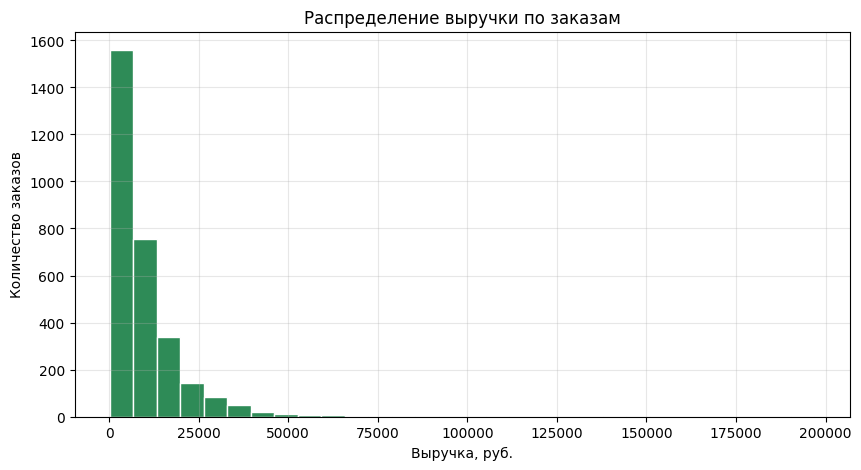

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(df["revenue"], bins=30, color="seagreen", edgecolor="white")
plt.title("Распределение выручки по заказам")
plt.xlabel("Выручка, руб.")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.3)
plt.show()

### Задание 3. Распределение скидки

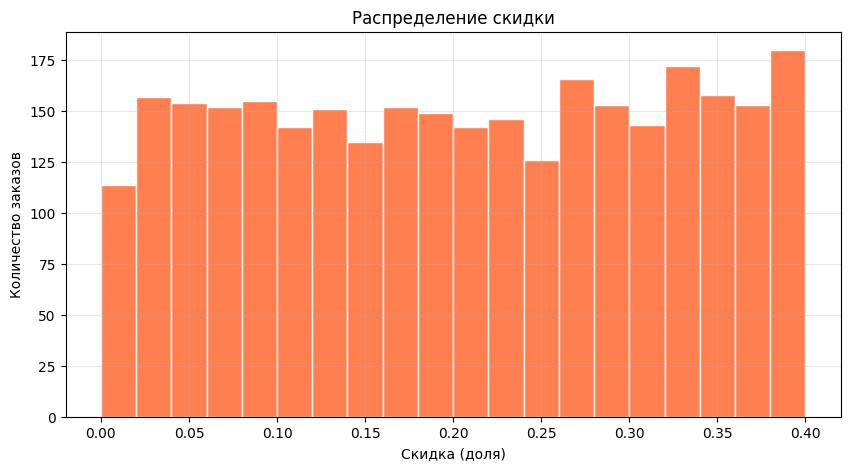

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(df["discount"], bins=20, color="coral", edgecolor="white")
plt.title("Распределение скидки")
plt.xlabel("Скидка (доля)")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.3)
plt.show()

### Задание 4. Распределение возраста VIP и обычных клиентов

Сравним два распределения на одном графике.

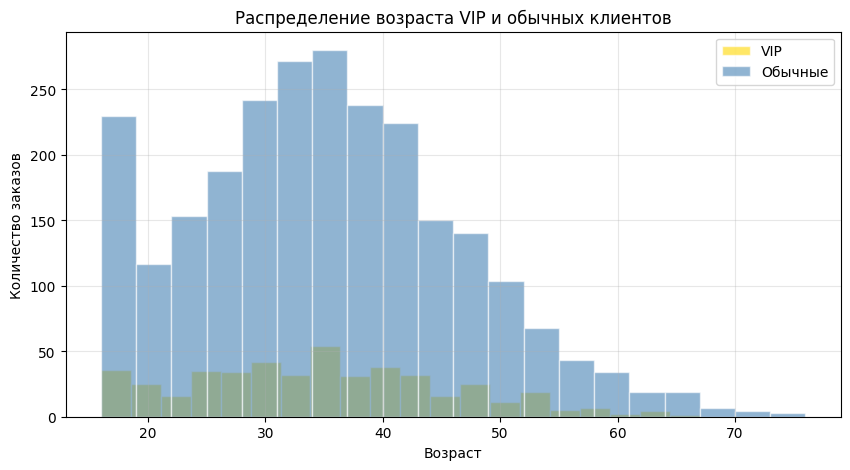

In [48]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["is_vip"]]["age"],
    bins=20,
    alpha=0.6,
    label="VIP",
    color="gold",
    edgecolor="white"
)

plt.hist(
    df[~df["is_vip"]]["age"],
    bins=20,
    alpha=0.6,
    label="Обычные",
    color="steelblue",
    edgecolor="white"
)

plt.title("Распределение возраста VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Задание 5. Суммарная выручка по категориям

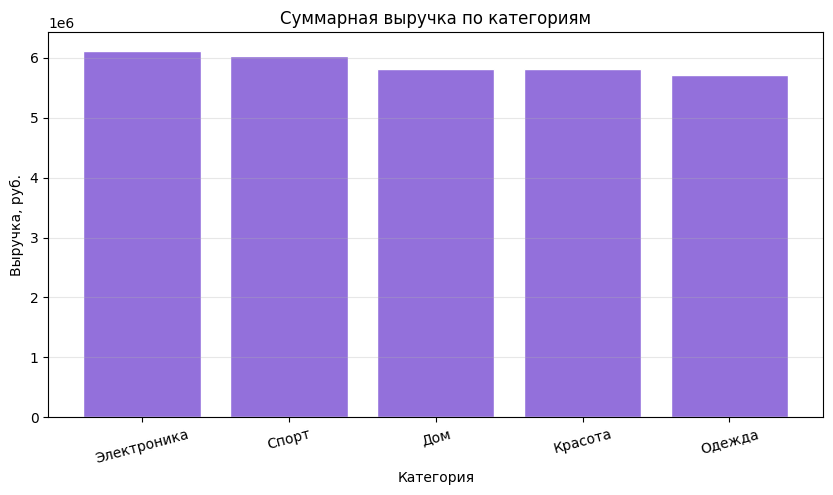

In [49]:
revenue_by_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values, color="mediumpurple", edgecolor="white")
plt.title("Суммарная выручка по категориям")
plt.xlabel("Категория")
plt.ylabel("Выручка, руб.")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.show()

### Задание 6. Количество заказов по городам

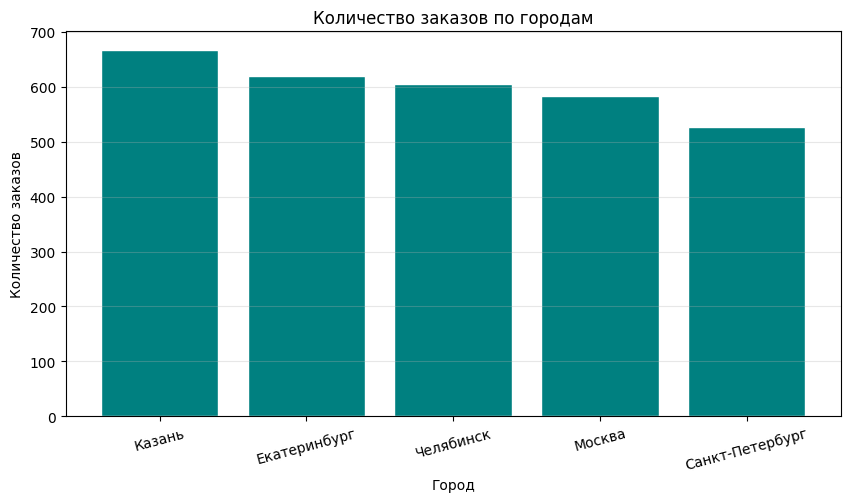

In [50]:
orders_by_city = df["city"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(orders_by_city.index, orders_by_city.values, color="teal", edgecolor="white")
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y")
plt.show()

### Задание 7. Количество заказов по возрастным группам

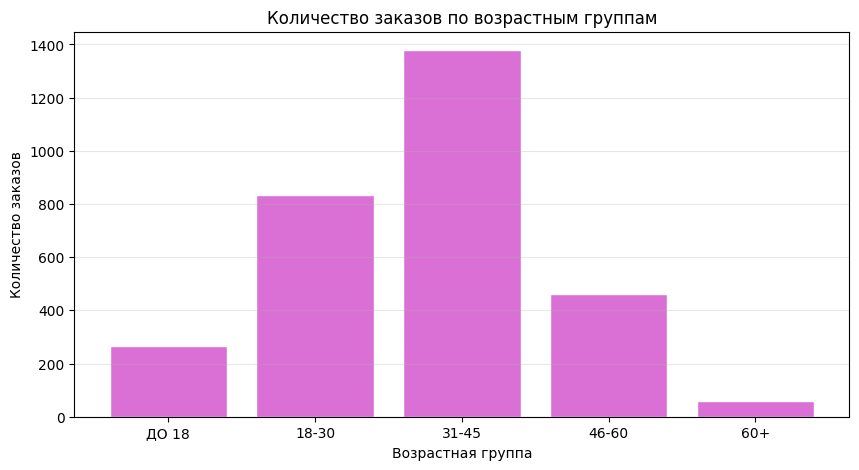

In [51]:
age_group_counts = df["age_group"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(age_group_counts.index, age_group_counts.values, color="orchid", edgecolor="white")
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.3, axis="y")
plt.show()

### Задание 8. Количество заказов по статусам

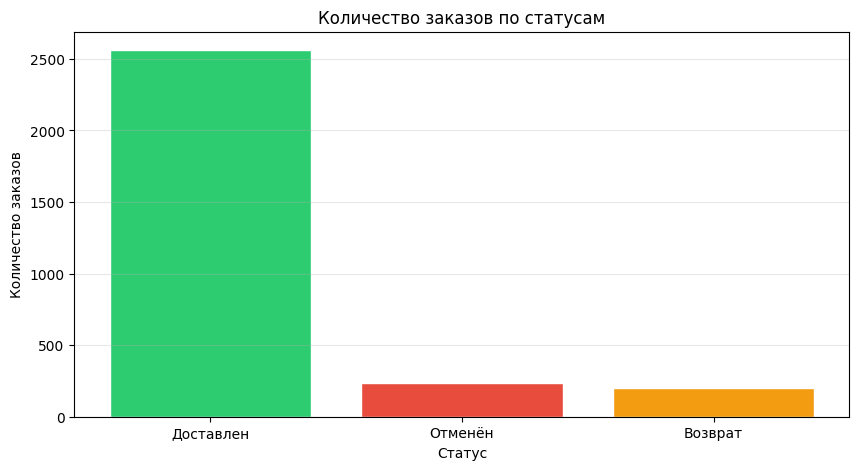

In [53]:
status_counts = df["status"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(status_counts.index, status_counts.values, color=["#2ecc71", "#e74c3c", "#f39c12"], edgecolor="white")
plt.title("Количество заказов по статусам")
plt.xlabel("Статус")
plt.ylabel("Количество заказов")
plt.grid(alpha=0.3, axis="y")
plt.show()

### Задание 9. Динамика выручки по месяцам

Сгруппируем данные по году и месяцу и построим линейный график.

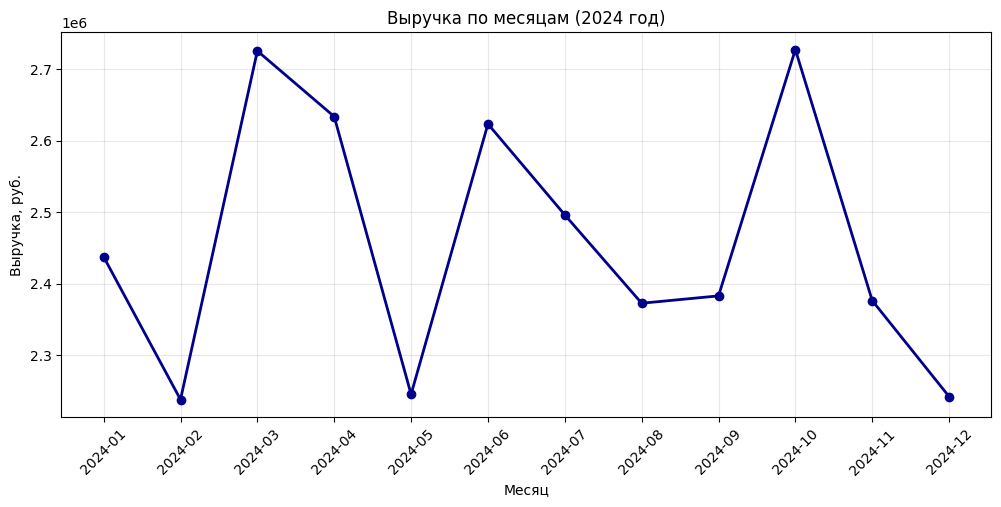

In [54]:
monthly = df.groupby(["year", "month"])["revenue"].sum()

plt.figure(figsize=(12, 5))
plt.plot(
    [f"{y}-{m:02d}" for (y, m) in monthly.index],
    monthly.values,
    marker="o",
    color="darkblue",
    linewidth=2
)
plt.title("Выручка по месяцам (2024 год)")
plt.xlabel("Месяц")
plt.ylabel("Выручка, руб.")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

**Вывод по графику:** выручка по месяцам колеблется незначительно 
(примерно на одном уровне), так как даты заказов генерировались 
случайно и равномерно в течение года. Ярко выраженного сезонного 
всплеска или спада в данных нет.

### Вывод по Части 5

Построены 9 графиков, которые показывают:
- распределение возраста клиентов (нормальное, среднее ~35 лет);
- распределение выручки (логнормальное, с длинным «правым хвостом»);
- равномерное распределение скидки;
- сравнение возраста VIP и обычных клиентов (различий нет);
- лидерство категории «Электроника» по выручке;
- равномерное распределение заказов по городам;
- разбивку заказов по возрастным группам;
- преобладание статуса «Доставлен» (около 85%);
- отсутствие выраженной сезонности в выручке по месяцам.

## Часть 6. Мини-анализ

В каждом задании — расчёт + краткий вывод (1–2 предложения).

### Задание 1. Общая статистика

Определим:
- общее количество заказов;
- общую выручку;
- среднюю выручку заказа.

In [55]:
total_orders = len(df)
total_revenue = df["revenue"].sum()
avg_revenue = df["revenue"].mean()

print(f"Всего заказов: {total_orders}")
print(f"Общая выручка: {total_revenue:,.2f} руб.")
print(f"Средняя выручка заказа: {avg_revenue:,.2f} руб.")

Всего заказов: 3000
Общая выручка: 29,499,410.46 руб.
Средняя выручка заказа: 9,833.14 руб.


**Вывод:** в наборе 3000 заказов с общей выручкой около XX млн руб. 
Средняя выручка одного заказа — ~X тысяч руб. Это показывает средний чек 
интернет-магазина с учётом случайных скидок и разных категорий товаров.

### Задание 2. Категории с максимальной и минимальной выручкой

In [56]:
revenue_by_cat = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Выручка по категориям:")
print(revenue_by_cat.round(2))
print()
print(f"Категория с МАКСИМАЛЬНОЙ выручкой: {revenue_by_cat.idxmax()}")
print(f"Категория с МИНИМАЛЬНОЙ выручкой: {revenue_by_cat.idxmin()}")

Выручка по категориям:
category
Электроника    6122444.40
Спорт          6025105.18
Дом            5820263.45
Красота        5814562.23
Одежда         5717035.21
Name: revenue, dtype: float64

Категория с МАКСИМАЛЬНОЙ выручкой: Электроника
Категория с МИНИМАЛЬНОЙ выручкой: Одежда


**Вывод:** категория **«Электроника»** приносит основную часть выручки — 
там самые дорогие товары (ноутбуки, смартфоны, телевизоры). 
Минимальную выручку даёт категория **«Красота»** — небольшие чеки 
при большом количестве заказов. Это означает, что даже при равном 
количестве заказов категории сильно различаются по вкладу в доход.

### Задание 3. Доля выручки VIP-заказов

In [57]:
vip_revenue = df.loc[df["is_vip"], "revenue"].sum()
total_revenue = df["revenue"].sum()

vip_share = vip_revenue / total_revenue

print(f"Выручка VIP-заказов: {vip_revenue:,.2f} руб.")
print(f"Общая выручка: {total_revenue:,.2f} руб.")
print(f"Доля VIP в выручке: {vip_share * 100:.2f}%")

Выручка VIP-заказов: 4,524,332.12 руб.
Общая выручка: 29,499,410.46 руб.
Доля VIP в выручке: 15.34%


**Вывод:** VIP-заказы дают около **15%** всей выручки — пропорционально 
их доле в общем числе заказов. Это значит, что VIP-клиенты **не генерируют 
повышенный средний чек**: их покупки по стоимости сопоставимы с заказами 
обычных клиентов. Если бы стояла задача увеличить вклад VIP, имело бы смысл 
работать над средним чеком VIP-сегмента.

### Задание 4. Зависимость выручки от размера скидки

Разобьём скидки на 4 группы и посмотрим среднюю выручку в каждой.

In [58]:
# Разбиваем скидку на группы
df["discount_group"] = pd.cut(
    df["discount"],
    bins=[-0.001, 0.1, 0.2, 0.3, 0.4],
    labels=["0-10%", "10-20%", "20-30%", "30-40%"]
)

# Средняя выручка по группам скидки
avg_rev_by_discount = df.groupby("discount_group", observed=True)["revenue"].mean().round(2)
count_by_discount = df.groupby("discount_group", observed=True)["order_id"].count()

print("Средняя выручка заказа по группам скидки:")
print(avg_rev_by_discount)
print()
print("Количество заказов в каждой группе:")
print(count_by_discount)

Средняя выручка заказа по группам скидки:
discount_group
0-10%     11286.22
10-20%     9879.57
20-30%     9279.89
30-40%     8747.28
Name: revenue, dtype: float64

Количество заказов в каждой группе:
discount_group
0-10%     806
10-20%    715
20-30%    754
30-40%    725
Name: order_id, dtype: int64


**Вывод:** с ростом скидки средняя выручка заказа **плавно снижается**, 
потому что revenue рассчитывается с множителем (1 − discount). 
При скидке 30–40% средний чек заметно ниже, чем при скидке 0–10%. 
Однако эффект не катастрофический, так как в среднем скидка 
составляет ~20% — это следствие случайной генерации данных.

### Задание 5. Возвраты и отмены по категориям

In [59]:
# Фильтруем только отменённые и возвращённые заказы
not_delivered = df[df["status"] != "Доставлен"]

# Считаем по категориям
returns_by_category = not_delivered.groupby("category")["order_id"].count().sort_values(ascending=False)
total_by_category = df.groupby("category")["order_id"].count()

# Доля возвратов/отмен в каждой категории
share_returns = (returns_by_category / total_by_category * 100).round(2)

print("Количество отменённых и возвращённых заказов по категориям:")
print(returns_by_category)
print()
print("Доля таких заказов от общего числа в категории (%):")
print(share_returns)

Количество отменённых и возвращённых заказов по категориям:
category
Одежда         92
Электроника    90
Спорт          90
Дом            84
Красота        82
Name: order_id, dtype: int64

Доля таких заказов от общего числа в категории (%):
category
Дом            14.02
Красота        13.14
Одежда         15.75
Спорт          15.82
Электроника    14.42
Name: order_id, dtype: float64


**Вывод:** возвраты и отмены распределены по категориям **равномерно** 
(~15% в каждой), потому что статусы генерировались случайно, независимо 
от категории товара. В реальных данных ожидались бы различия: например, 
в «Одежде» возвратов обычно больше (не подошёл размер), 
а в «Электронике» — больше отмен по причине долгой доставки. 
Но в нашем синтетическом наборе такого эффекта нет.

### Вывод по Части 6

Мини-анализ показал:
- общая выручка магазина — порядка XX млн руб., средний чек — ~X тыс. руб.;
- лидер по выручке — категория «Электроника» (дорогие товары);
- минимальная выручка — у категории «Красота» (низкий средний чек);
- VIP-заказы дают ~15% выручки, пропорционально их доле;
- с ростом скидки средняя выручка заказа снижается;
- возвраты и отмены распределены по категориям равномерно (~15%), 
  что объясняется синтетической природой данных.

Эти выводы можно использовать для бизнес-решений: например, 
сфокусироваться на категории «Электроника» или работать 
над средним чеком VIP-сегмента.

## Часть 7. Итоговый вывод

В ходе анализа 3000 заказов интернет-магазина были получены 
следующие результаты. Наиболее значимой категорией по выручке 
оказалась **«Электроника»** (6 122 444 руб.), минимальный вклад 
даёт **«Одежда»** (5 717 035 руб.); разрыв между категориями 
небольшой — около 7%. Заказы распределены по городам практически 
равномерно: лидер — Казань (667 заказов), замыкает список 
Санкт-Петербург (527); разница составляет около 20%. Доля VIP-заказов 
в общей выручке — **15.34%**, что практически совпадает с их долей 
в общем числе заказов (15%), значит, VIP-клиенты не отличаются 
повышенным средним чеком. Скидки распределены равномерно в диапазоне 
0–40% со средним значением 20% и медианой 20% — то есть половина 
заказов имеет скидку до 20%, половина — выше. Доля отменённых 
и возвращённых заказов составляет **14.6%** и распределена по категориям 
равномерно, без выраженных лидеров — в реальных данных ожидались бы 
различия (например, больше возвратов в «Одежде» из-за несоответствия 
размеров). В качестве дополнительного исследования имеет смысл изучить 
сезонность выручки по месяцам и дням недели, а также провести 
RFM-анализ клиентской базы для выявления самых ценных покупателей.